In [1]:
# importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# loading the dataset
health_data_cleaned = pd.read_excel('../DATASETS/healthcare_dataset_cleaned.xlsx', engine='calamine')
health_data_cleaned.head()



,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Aaron Adams,38,Female,O-,Cancer,2021-03-10,Norma Li,Hart LLC,UnitedHealthcare,26052.106404,363,Elective,2021-03-29,Lipitor,Inconclusive
1,Aaron Aguirre,36,Male,A-,Diabetes,2023-02-26,Katrina Luna,Murray-Shelton,UnitedHealthcare,27087.560553,300,Emergency,2023-03-13,Aspirin,Inconclusive
2,Aaron Anderson,50,Female,A+,Asthma,2020-12-18,Kenneth Jennings,Tanner-Cox,Cigna,39804.658624,196,Urgent,2021-01-15,Aspirin,Inconclusive
3,Aaron Anderson Md,20,Female,A-,Hypertension,2021-03-28,Tammy Perez,Ritter LLC,UnitedHealthcare,16846.415799,249,Elective,2021-04-09,Paracetamol,Abnormal
4,Aaron Archer,47,Female,B-,Cancer,2021-01-10,Cynthia Villanueva,"Montes Case and Mendez,",Medicare,10602.077185,108,Urgent,2021-01-17,Paracetamol,Inconclusive


In [3]:
# shape of the dataset
health_data_cleaned.shape

(54966, 15)

In [4]:
#information about the dataset
health_data_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                54966 non-null  str           
 1   Age                 54966 non-null  int64         
 2   Gender              54966 non-null  str           
 3   Blood Type          54966 non-null  str           
 4   Medical Condition   54966 non-null  str           
 5   Date of Admission   54966 non-null  datetime64[us]
 6   Doctor              54966 non-null  str           
 7   Hospital            54966 non-null  str           
 8   Insurance Provider  54966 non-null  str           
 9   Billing Amount      54966 non-null  float64       
 10  Room Number         54966 non-null  int64         
 11  Admission Type      54966 non-null  str           
 12  Discharge Date      54966 non-null  datetime64[us]
 13  Medication          54966 non-null  str           
 14  T

In [5]:
# Statistical summary of the dataset
health_data_cleaned.describe().T

,count,mean,min,25%,50%,75%,max,std
Age,54966.0,51.535185,13.0,35.0,52.0,68.0,89.0,19.605661
Date of Admission,54966,2021-11-01 17:35:29.505512,2019-05-08 00:00:00,2020-07-28 00:00:00,2021-11-02 00:00:00,2023-02-03 00:00:00,2024-05-07 00:00:00,NaN
Billing Amount,54966.0,25544.306284,-2008.49214,13243.718641,25542.749145,37819.858159,52764.276736,14208.409711
Room Number,54966.0,301.124404,101.0,202.0,302.0,401.0,500.0,115.223143
Discharge Date,54966,2021-11-17 05:34:28.202161,2019-05-09 00:00:00,2020-08-13 00:00:00,2021-11-18 00:00:00,2023-02-19 00:00:00,2024-06-06 00:00:00,NaN


### EXPLORATORY DATA ANALYSIS AND VISUALIZATION

In [3]:
# separting the columns into categorical and numerical columns
categorical_columns = health_data_cleaned.select_dtypes(include=['str']).columns
numerical_columns = health_data_cleaned.select_dtypes(include=['int64', 'float64']).columns
date_columns = health_data_cleaned.select_dtypes(include=['datetime64']).columns

In [7]:
numerical_columns

Index(['Age', 'Billing Amount', 'Room Number'], dtype='str')

Text(0.5, 1.0, 'Distribution of Age')

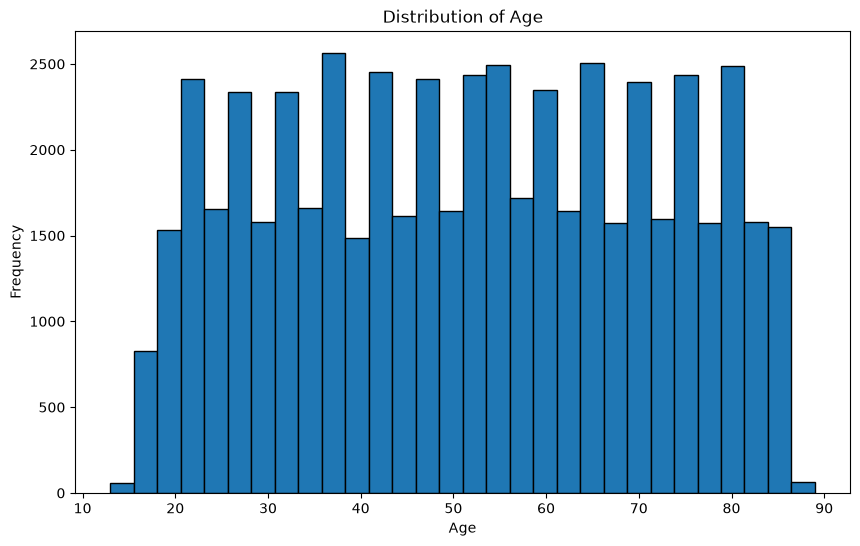

In [8]:
# Distribution of Age
plt.figure(figsize=(10, 6))
plt.hist(health_data_cleaned['Age'], bins=30, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')


Text(0.5, 1.0, 'Distribution of Billing Amount')

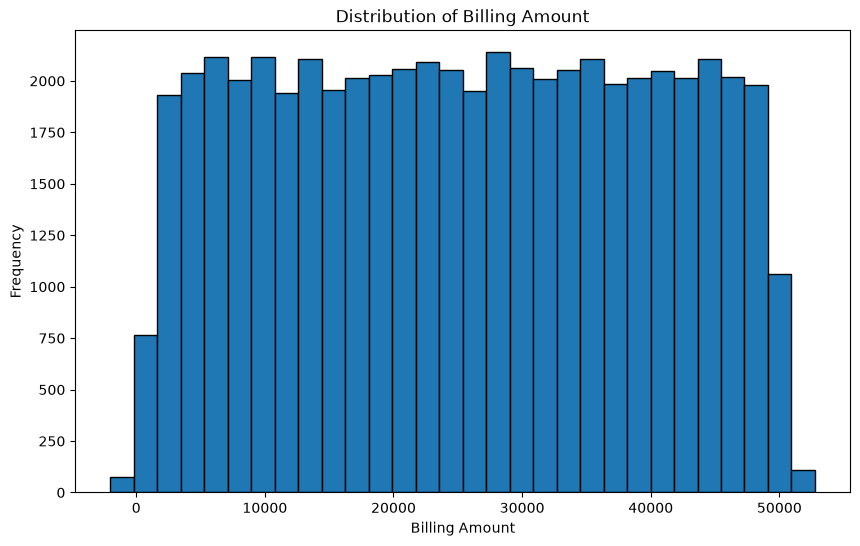

In [9]:
# Distribution of Billing Amount
plt.figure(figsize=(10, 6))
plt.hist(health_data_cleaned['Billing Amount'], bins=30, edgecolor='black')
plt.xlabel('Billing Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Billing Amount')

In [10]:
# Categorical columns
categorical_columns

Index(['Name', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor',
       'Hospital', 'Insurance Provider', 'Admission Type', 'Medication',
       'Test Results'],
      dtype='str')

In [4]:
# Removing the column 'name'
health_data_cleaned = health_data_cleaned.drop(columns=['Name'])



Text(0, 0.5, 'Count')

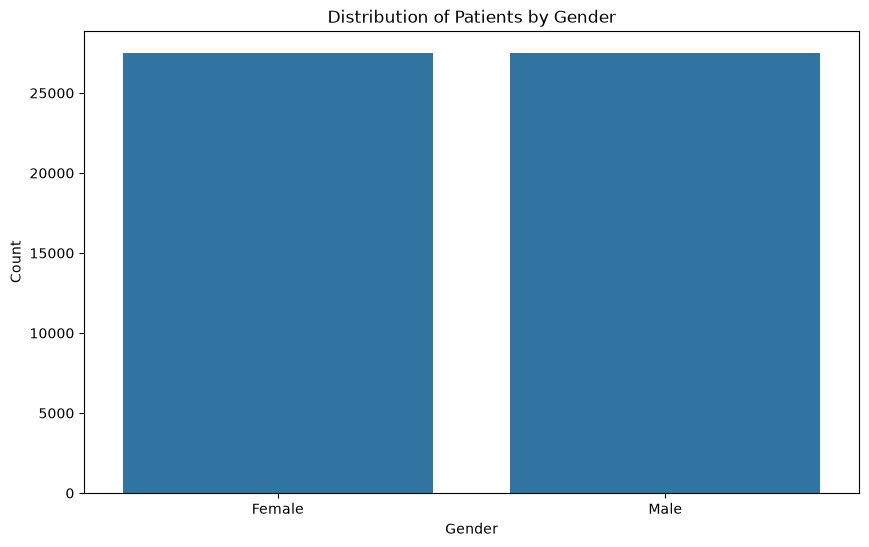

In [12]:
# Distribution of patients by Gender
plt.figure(figsize=(10, 6))
sns.countplot(data=health_data_cleaned, x='Gender')
plt.title('Distribution of Patients by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Cancer'),
  Text(1, 0, 'Diabetes'),
  Text(2, 0, 'Asthma'),
  Text(3, 0, 'Hypertension'),
  Text(4, 0, 'Obesity'),
  Text(5, 0, 'Arthritis')])

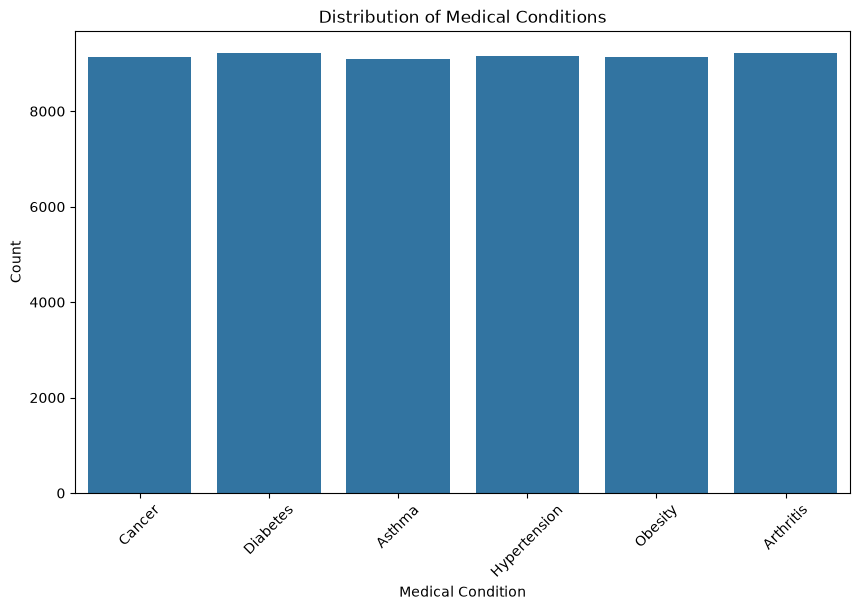

In [13]:
# Distribution of Medical Condition
plt.figure(figsize=(10, 6))
sns.countplot(data=health_data_cleaned, x='Medical Condition')
plt.title('Distribution of Medical Conditions')
plt.xlabel('Medical Condition')
plt.ylabel('Count')
plt.xticks(rotation=45)

In [15]:
# Distribution of medical conditions by blood type
count_table = pd.crosstab(
    index=health_data_cleaned['Blood Type'], 
    columns=health_data_cleaned['Medical Condition'], 
    margins=True,          # Adds the 'All' totals row and column
    margins_name='Total'   # Renames the margin label
)

count_table

Medical Condition,Arthritis,Asthma,Cancer,Diabetes,Hypertension,Obesity,Total
Blood Type,,,,,,,
A+,1107,1124,1171,1201,1123,1170,6896
A-,1144,1162,1124,1154,1186,1128,6898
AB+,1124,1173,1100,1165,1204,1116,6882
AB-,1179,1123,1186,1132,1108,1146,6874
B+,1191,1104,1186,1180,1087,1137,6885
B-,1152,1108,1131,1136,1163,1182,6872
O+,1186,1162,1098,1142,1145,1122,6855
O-,1135,1139,1144,1106,1135,1145,6804
Total,9218,9095,9140,9216,9151,9146,54966


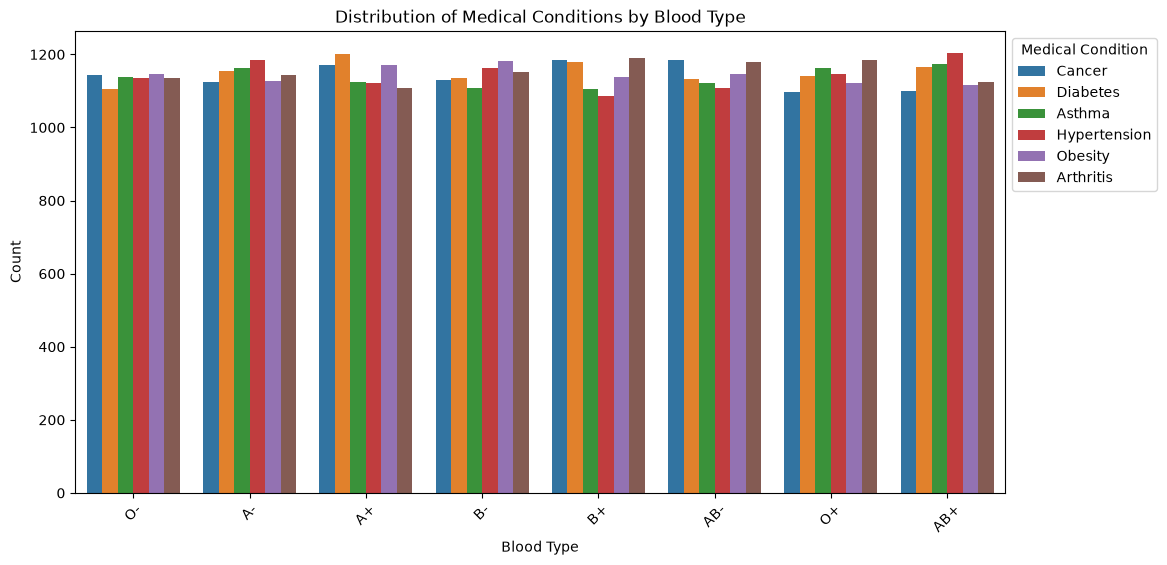

In [16]:
# Distribution of medical conditions by blood type
plt.figure(figsize=(12, 6))
sns.countplot(data=health_data_cleaned, x='Blood Type', hue='Medical Condition')
plt.title('Distribution of Medical Conditions by Blood Type')
plt.xlabel('Blood Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.legend(title='Medical Condition', bbox_to_anchor=(1, 1), loc='upper left')


In [17]:
# 1. Create the table as percentages (rows sum to 1.0)
percentage_table = pd.crosstab(
    index=health_data_cleaned['Blood Type'], 
    columns=health_data_cleaned['Medical Condition'], 
    normalize='index'
)

# 2. Multiply by 100 and format as a clean percentage string
formatted_table = (percentage_table * 100).round(1).astype(str) + '%'

print(formatted_table)

Medical Condition Arthritis Asthma Cancer Diabetes Hypertension Obesity
Blood Type                                                             
A+                    16.1%  16.3%  17.0%    17.4%        16.3%   17.0%
A-                    16.6%  16.8%  16.3%    16.7%        17.2%   16.4%
AB+                   16.3%  17.0%  16.0%    16.9%        17.5%   16.2%
AB-                   17.2%  16.3%  17.3%    16.5%        16.1%   16.7%
B+                    17.3%  16.0%  17.2%    17.1%        15.8%   16.5%
B-                    16.8%  16.1%  16.5%    16.5%        16.9%   17.2%
O+                    17.3%  17.0%  16.0%    16.7%        16.7%   16.4%
O-                    16.7%  16.7%  16.8%    16.3%        16.7%   16.8%


In [5]:
# Medical Condition Distribution by Age Group
# Creating age groups
health_data_cleaned['Age Group'] = pd.cut(health_data_cleaned['Age'], bins=[0, 18, 35, 50, 65, 100], labels=['0-18', '19-35', '36-50', '51-65', '66+'])
health_data_cleaned['Age Group'].value_counts(normalize=True) * 100
    

Age Group
66+      29.283557
19-35    24.595204
51-65    22.373831
36-50    22.135502
0-18      1.611906
Name: proportion, dtype: float64

([0, 1, 2, 3, 4],
 [Text(0, 0, '0-18'),
  Text(1, 0, '19-35'),
  Text(2, 0, '36-50'),
  Text(3, 0, '51-65'),
  Text(4, 0, '66+')])

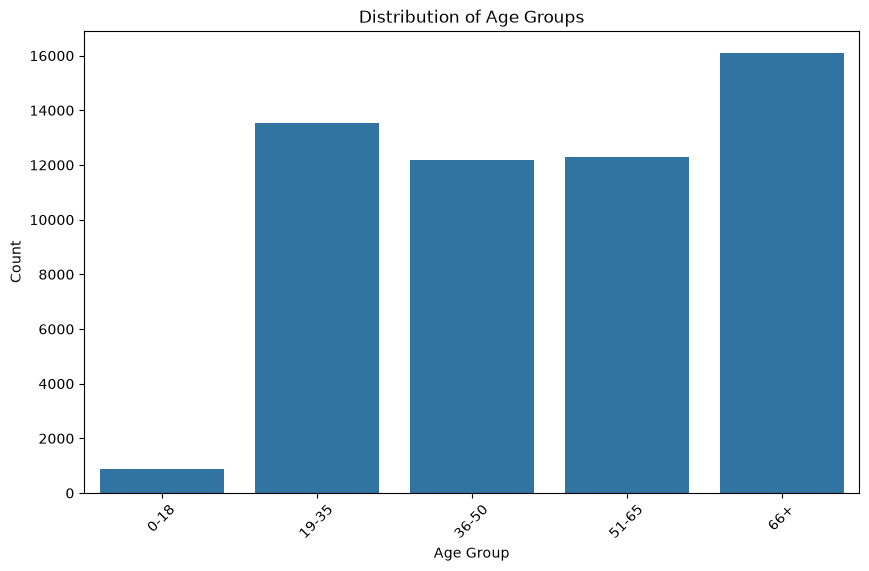

In [19]:
# Distribution of Age Groups
plt.figure(figsize=(10, 6))
sns.countplot(data=health_data_cleaned, x='Age Group')
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)

([0, 1, 2, 3, 4],
 [Text(0, 0, '0-18'),
  Text(1, 0, '19-35'),
  Text(2, 0, '36-50'),
  Text(3, 0, '51-65'),
  Text(4, 0, '66+')])

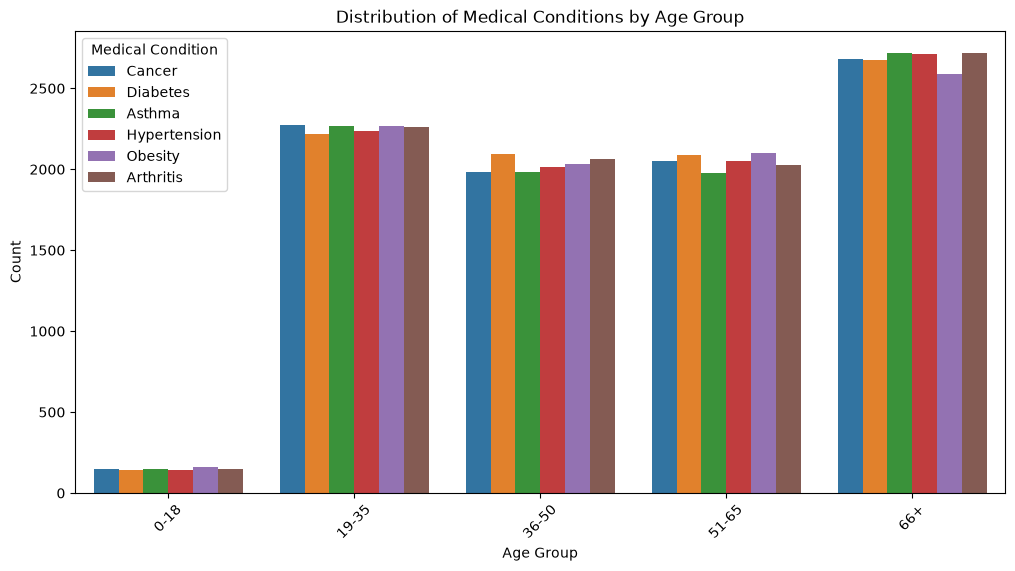

In [20]:
# Distribution of Medical Conditions by Age Group
plt.figure(figsize=(12, 6))
sns.countplot(data=health_data_cleaned, x='Age Group', hue='Medical Condition')
plt.title('Distribution of Medical Conditions by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Medical Condition')
plt.xticks(rotation=45)


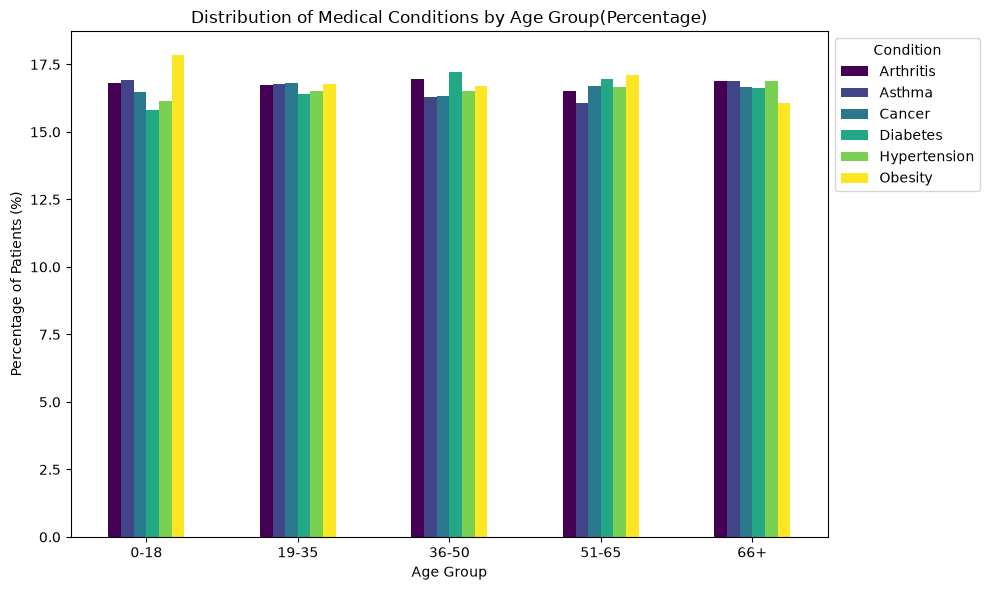

In [21]:
# Create the percentage table
percentage_table = pd.crosstab(
    index=health_data_cleaned['Age Group'], 
    columns=health_data_cleaned['Medical Condition'],
    normalize='index' # Normalizes across the rows (Age Groups)
)


# # Format for readability
# formatted_age_table = (percentage_table * 100).round(1).astype(str) + '%'

# print(formatted_age_table)

(percentage_table * 100).plot(
    kind='bar', 
    stacked=False, 
    figsize=(10, 6),
    colormap='viridis' # A colorblind-friendly palette
)

plt.title('Distribution of Medical Conditions by Age Group(Percentage)')    
plt.xlabel('Age Group')
plt.ylabel('Percentage of Patients (%)')
plt.xticks(rotation=0)

# Move the legend outside the plot
plt.legend(title='Condition', bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()

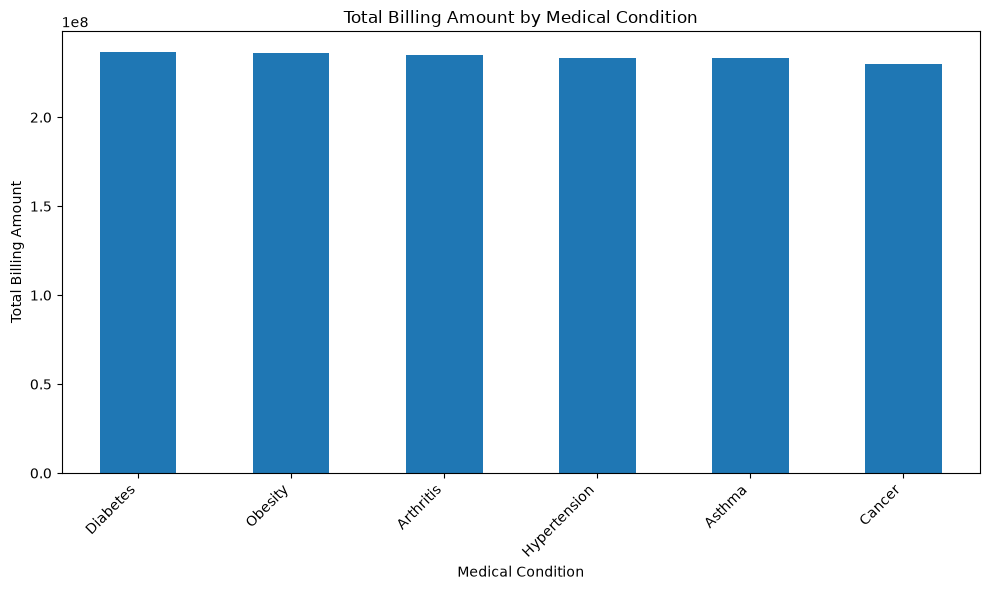

In [22]:
# Total and  billing amount by medical condition
billing_by_condition = health_data_cleaned.groupby('Medical Condition')['Billing Amount'].sum().sort_values(ascending=False)
billing_by_condition.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Medical Condition')
plt.ylabel('Total Billing Amount')
plt.title('Total Billing Amount by Medical Condition')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

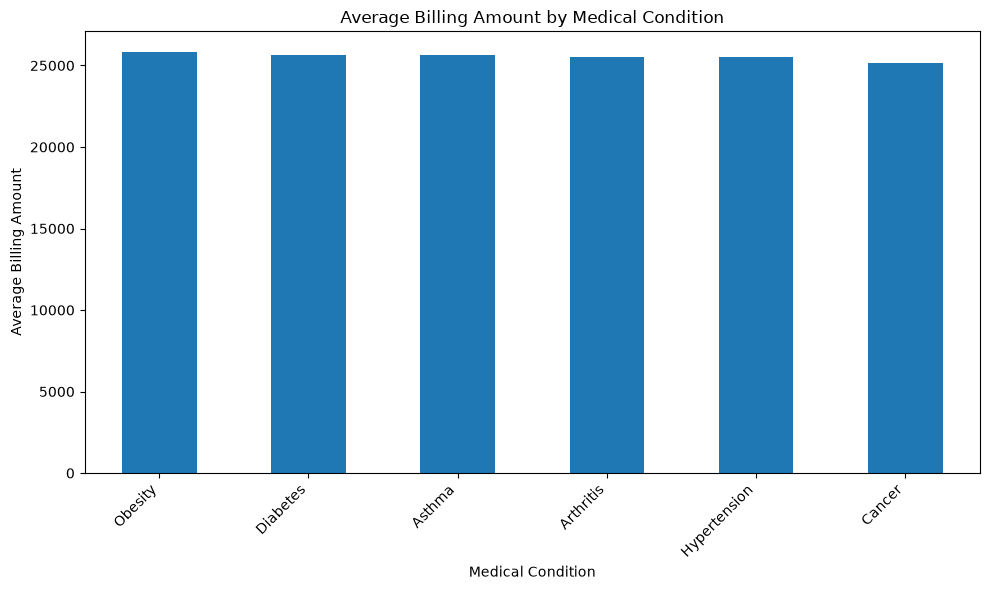

In [23]:
# Average billing amount by medical condition
average_billing_by_condition = health_data_cleaned.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)
average_billing_by_condition.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Medical Condition')
plt.ylabel('Average Billing Amount')
plt.title('Average Billing Amount by Medical Condition')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

<Figure size 1200x600 with 0 Axes>

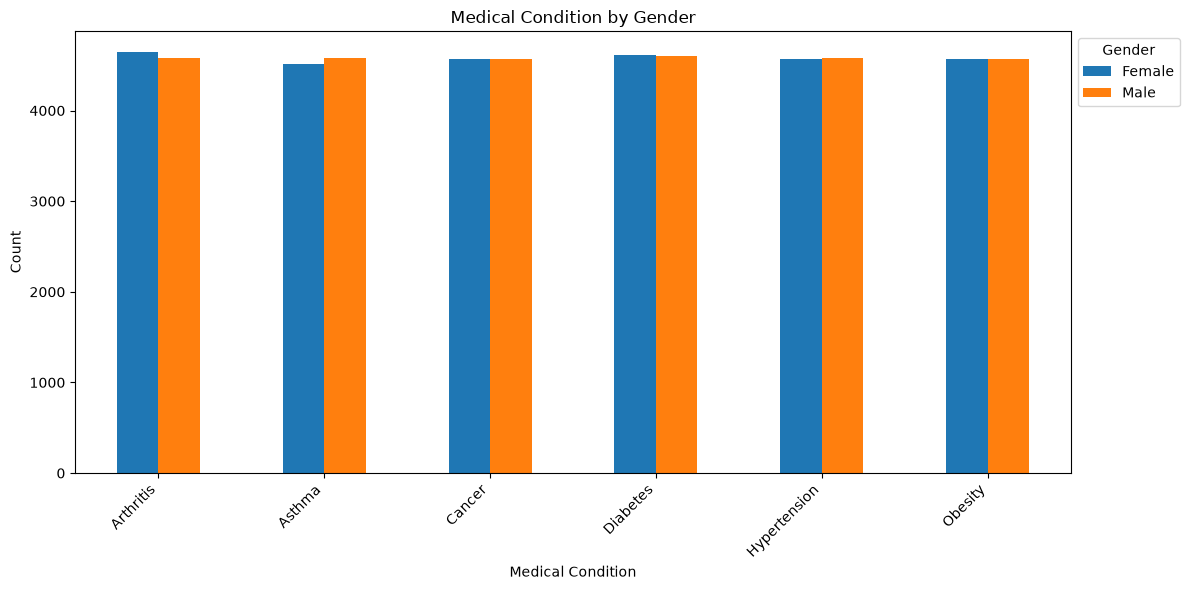

In [24]:
# Medical Condition by Gender
plt.figure(figsize=(12, 6))
health_data_cleaned.groupby(['Medical Condition', 'Gender']).size().unstack(fill_value=0).plot(kind='bar', stacked=False, figsize=(12, 6))
plt.xlabel('Medical Condition')
plt.ylabel('Count')
plt.title('Medical Condition by Gender')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()

<Figure size 1200x600 with 0 Axes>

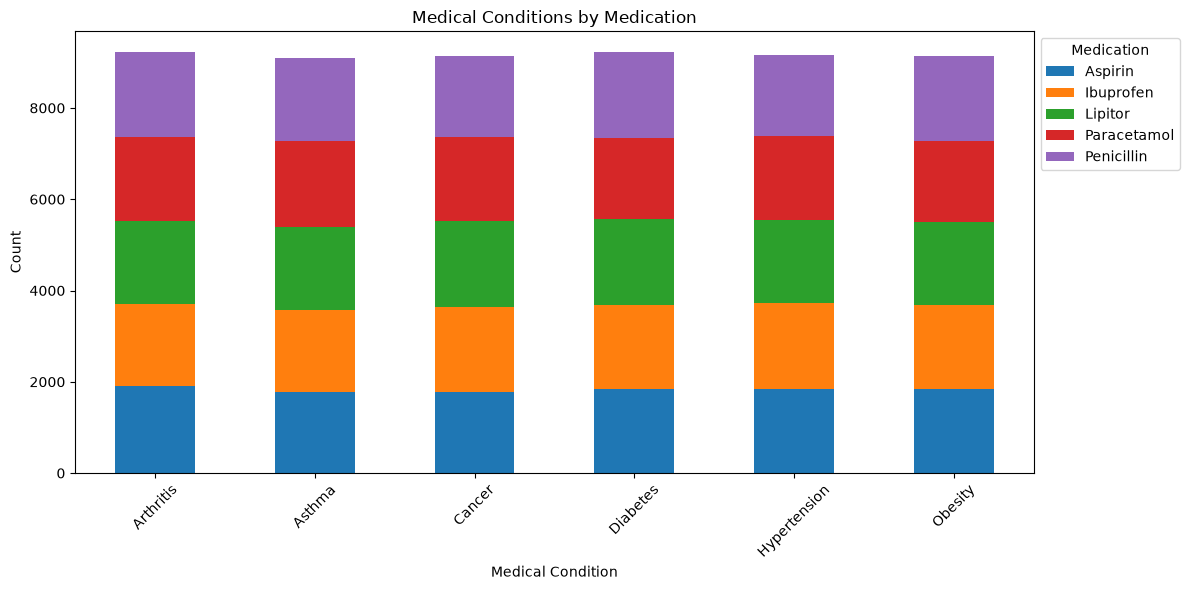

In [26]:
# MMedical Condition by Medications
plt.figure(figsize=(12, 6))
pd.crosstab(health_data_cleaned['Medical Condition'], health_data_cleaned['Medication'])
pd.crosstab(health_data_cleaned['Medical Condition'], health_data_cleaned['Medication']).plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('Medical Condition')
plt.ylabel('Count')
plt.title('Medical Conditions by Medication')
plt.xticks(rotation=45)
plt.legend(title='Medication', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()






<Figure size 1200x600 with 0 Axes>

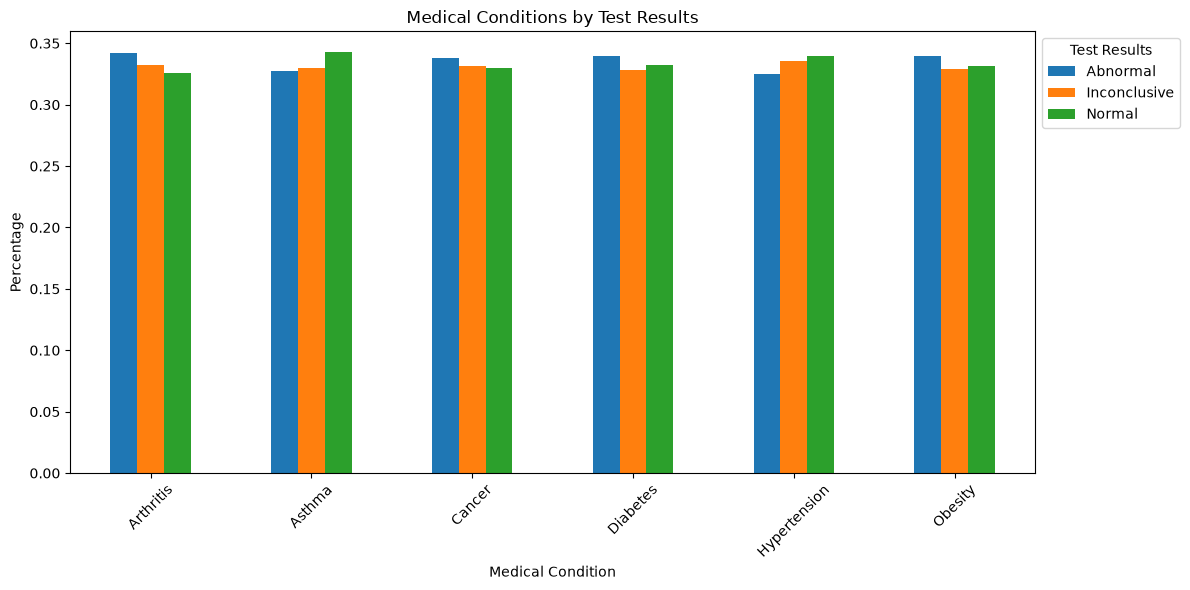

In [27]:
# Medical Condition by Test Results(percentage)
plt.figure(figsize=(12, 6))
pd.crosstab(health_data_cleaned['Medical Condition'], health_data_cleaned['Test Results'], normalize='index').plot(kind='bar', stacked=False, figsize=(12, 6))
plt.xlabel('Medical Condition')
plt.ylabel('Percentage')
plt.title('Medical Conditions by Test Results')
plt.xticks(rotation=45)
plt.legend(title='Test Results', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()

In [28]:
# Percentage of medical conditions by test results(table)
percentage_table_test_results = pd.crosstab(health_data_cleaned['Medical Condition'], health_data_cleaned['Test Results'], normalize='index') * 100
percentage_table_test_results

Test Results,Abnormal,Inconclusive,Normal
Medical Condition,,,
Arthritis,34.237362,33.217618,32.545021
Asthma,32.765256,32.974162,34.260583
Cancer,33.796499,33.183807,33.019694
Diabetes,33.973524,32.812500,33.213976
Hypertension,32.531964,33.526391,33.941646
Obesity,33.938334,32.932429,33.129237


In [29]:
# Top 10 Hospitals with the highest number of cases
hospital_counts = health_data_cleaned['Hospital'].value_counts().head(10)
hospital_counts

Hospital
LLC Smith      44
Ltd Smith      39
Smith Ltd      37
Johnson PLC    37
Smith Group    36
Smith PLC      36
Johnson Inc    34
Smith Inc      33
Group Smith    32
Smith LLC      32
Name: count, dtype: int64

In [30]:
# Top 10 Doctors with the highest number of cases
doctor_counts = health_data_cleaned['Doctor'].value_counts().head(10)
doctor_counts

Doctor
Michael Smith       27
John Smith          22
Robert Smith        21
James Smith         20
Michael Johnson     20
Robert Johnson      19
David Smith         19
Michael Williams    18
Matthew Smith       17
John Johnson        17
Name: count, dtype: int64

Text(0, 0.5, 'Count')

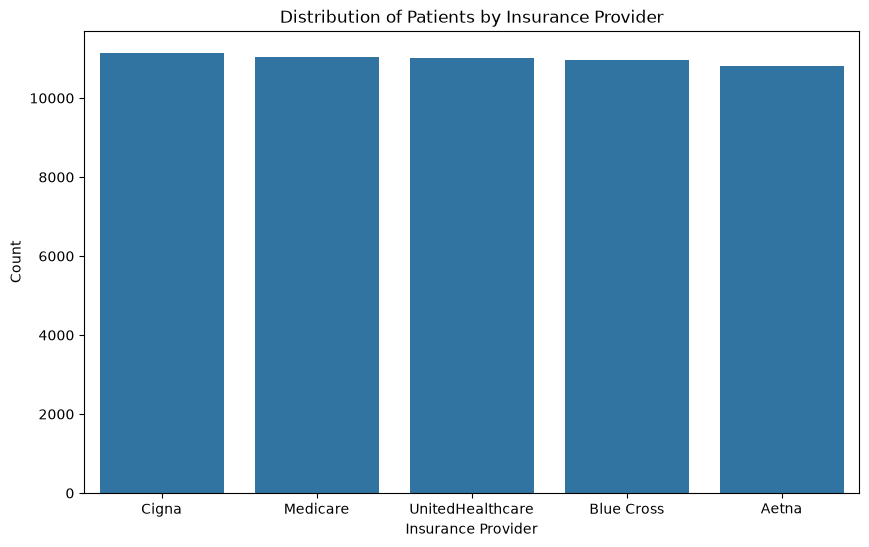

In [31]:
# Insurance Providers with the highest number of patients(chart)
plt.figure(figsize=(10, 6))
sns.countplot(data=health_data_cleaned, x='Insurance Provider', order=health_data_cleaned['Insurance Provider'].value_counts().index)
plt.title('Distribution of Patients by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Count')

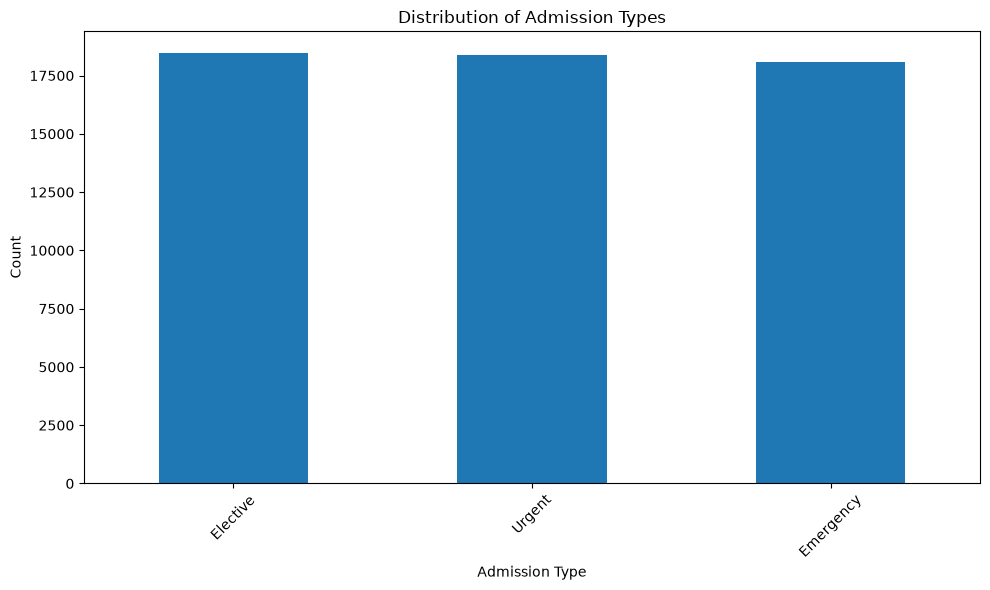

In [32]:
# Admission types distribution
plt.figure(figsize=(10, 6))
health_data_cleaned['Admission Type'].value_counts().plot(kind='bar')
plt.title('Distribution of Admission Types')
plt.xlabel('Admission Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

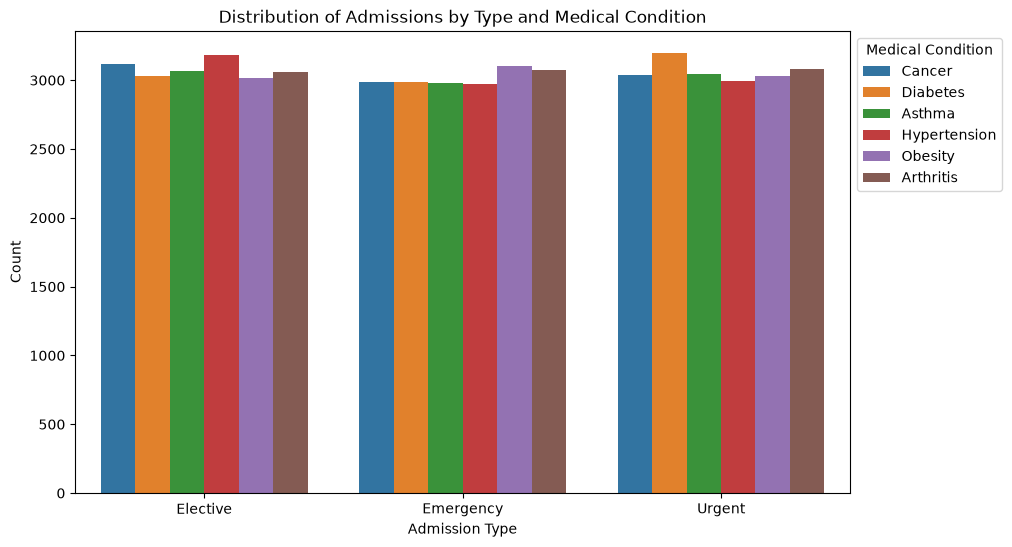

In [33]:
# Admmission Type by Medical Condition
plt.figure(figsize=(10, 6))
sns.countplot(data=health_data_cleaned, x='Admission Type', hue='Medical Condition')
plt.title('Distribution of Admissions by Type and Medical Condition')
plt.xlabel('Admission Type')
plt.ylabel('Count')
plt.legend(title='Medical Condition', bbox_to_anchor=(1, 1), loc='upper left')


Text(0, 0.5, 'Billing Amount')

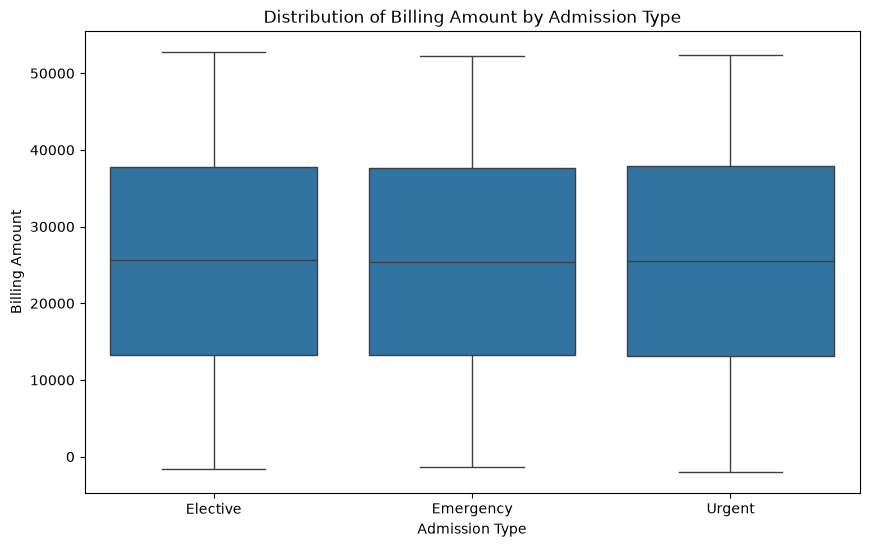

In [34]:
# Admission Type And Billing Amount
plt.figure(figsize=(10, 6))
sns.boxplot(data=health_data_cleaned, x='Admission Type', y='Billing Amount')
plt.title('Distribution of Billing Amount by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Billing Amount')

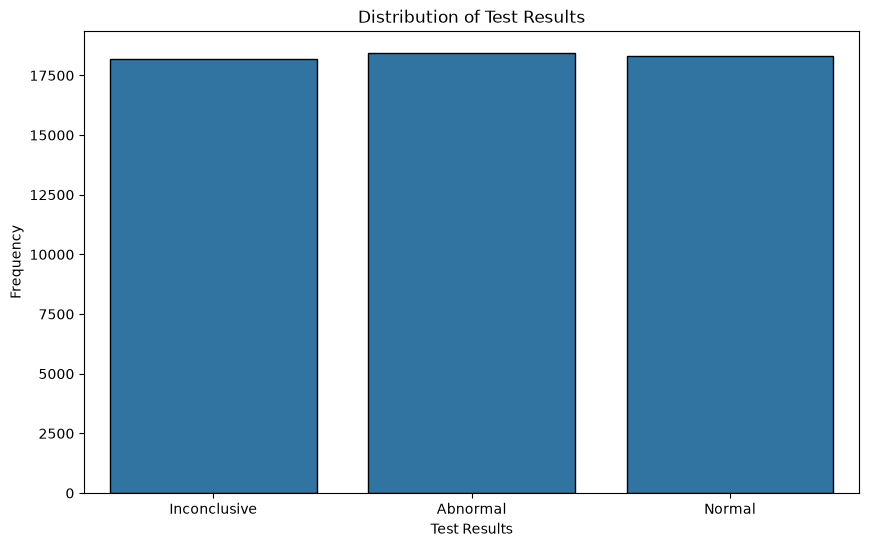

In [34]:
# Distribution of Test Results
plt.figure(figsize=(10, 6))
sns.countplot(x='Test Results', data=health_data_cleaned, edgecolor='black')
plt.xlabel('Test Results')
plt.ylabel('Frequency')
plt.title('Distribution of Test Results')
plt.show()

#### Time Trends

In [35]:
date_columns

Index(['Date of Admission', 'Discharge Date'], dtype='str')

In [ ]:
# Creating a new column for the length of stay
health_data_cleaned['Length of Stay'] = (health_data_cleaned['Discharge Date'] - health_data_cleaned['Date of Admission']).dt.days
health_data_cleaned[['Date of Admission', 'Discharge Date', 'Length of Stay']].head()

,Date of Admission,Discharge Date,Length of Stay
0,2021-03-10,2021-03-29,19
1,2023-02-26,2023-03-13,15
2,2020-12-18,2021-01-15,28
3,2021-03-28,2021-04-09,12
4,2021-01-10,2021-01-17,7


In [11]:
# Creating new columns for year, month and day of the week of admission
health_data_cleaned['Admission Year'] = health_data_cleaned['Date of Admission'].dt.year
health_data_cleaned['Admission Month'] = health_data_cleaned['Date of Admission'].dt.month
health_data_cleaned['Admission Day of Week'] = health_data_cleaned['Date of Admission'].dt.day_of_week
health_data_cleaned[['Date of Admission', 'Admission Year', 'Admission Month', 'Admission Day of Week']].head()

,Date of Admission,Admission Year,Admission Month,Admission Day of Week
0,2021-03-10,2021,3,2
1,2023-02-26,2023,2,6
2,2020-12-18,2020,12,4
3,2021-03-28,2021,3,6
4,2021-01-10,2021,1,6


Text(0.5, 1.0, 'Trend of Patient Admissions Over Time')

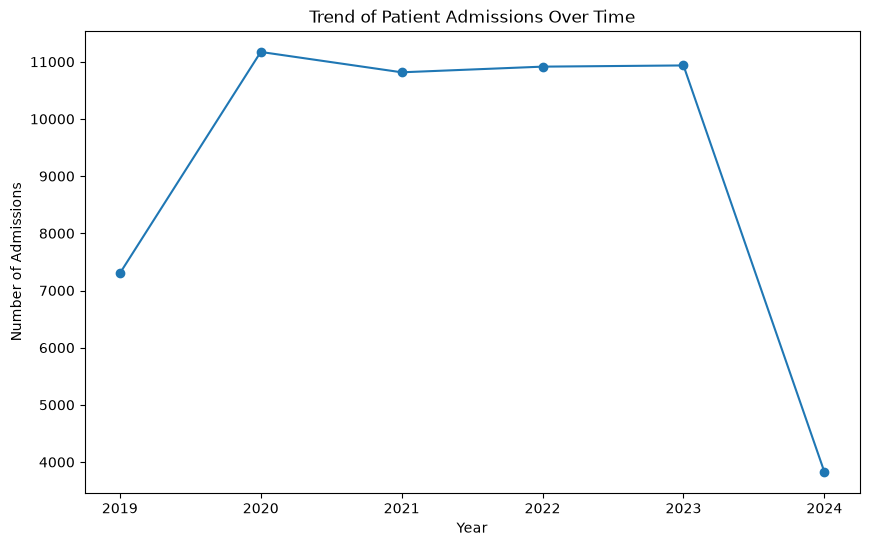

In [13]:
# Trend of Patients Admission over time(chart)
admission_trend = health_data_cleaned.groupby('Admission Year').size()
admission_trend.plot(kind='line', marker='o', figsize=(10, 6))
plt.xlabel('Year')
plt.ylabel('Number of Admissions')
plt.title('Trend of Patient Admissions Over Time')

Text(0.5, 1.0, 'Trend of Patient Admissions by Month')

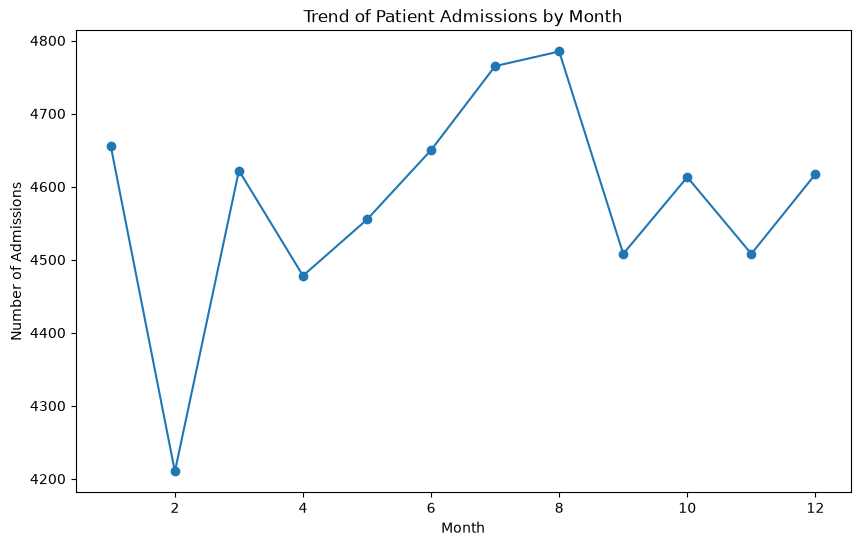

In [17]:
# Trends Of Patient Admissions by Month
admission_trend_month = health_data_cleaned.groupby('Admission Month').size()
admission_trend_month.plot(kind='line', marker='o', figsize=(10, 6))
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.title('Trend of Patient Admissions by Month')

Text(0.5, 1.0, 'Trend of Patient Admissions by Day of the Week')

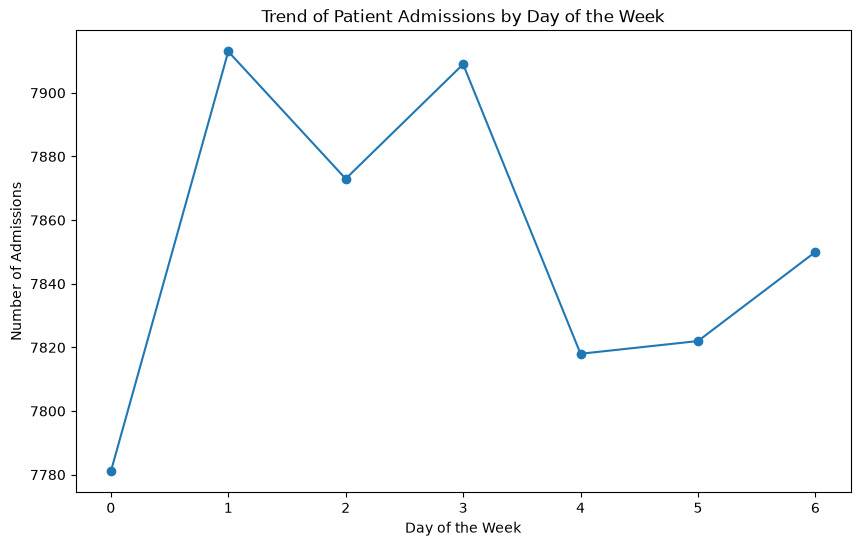

In [16]:
# Trend of Patient admissions by Day of the Week
admission_trend_day = health_data_cleaned.groupby('Admission Day of Week').size()
admission_trend_day.plot(kind='line', marker='o', figsize=(10, 6))
plt.xlabel('Day of the Week')
plt.ylabel('Number of Admissions')
plt.title('Trend of Patient Admissions by Day of the Week')

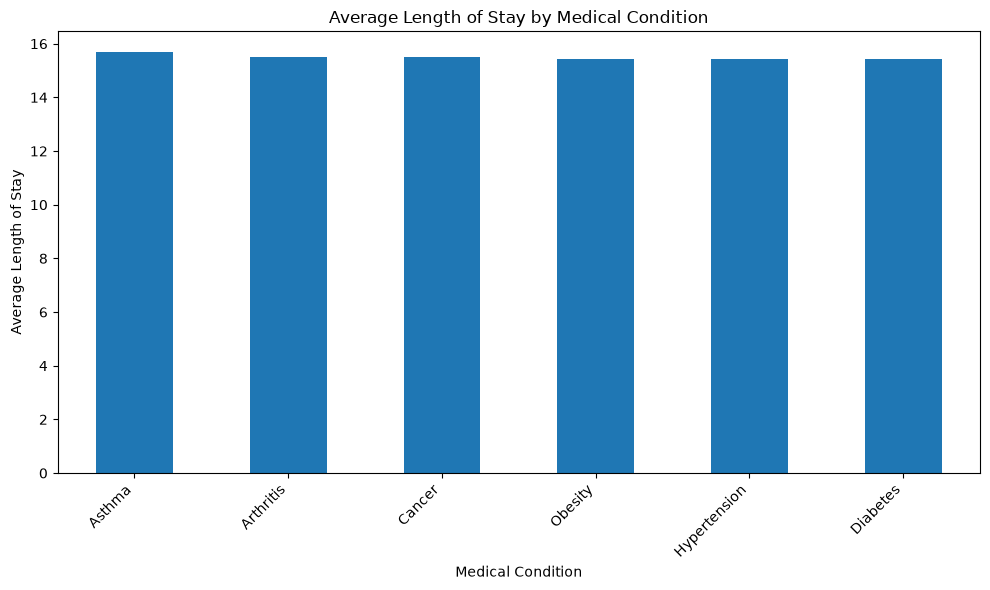

In [18]:
# Average Length of Stay by Medical Condition
average_length_of_stay = health_data_cleaned.groupby('Medical Condition')['Length of Stay'].mean().sort_values(ascending=False)
average_length_of_stay.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Medical Condition')
plt.ylabel('Average Length of Stay')
plt.title('Average Length of Stay by Medical Condition')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

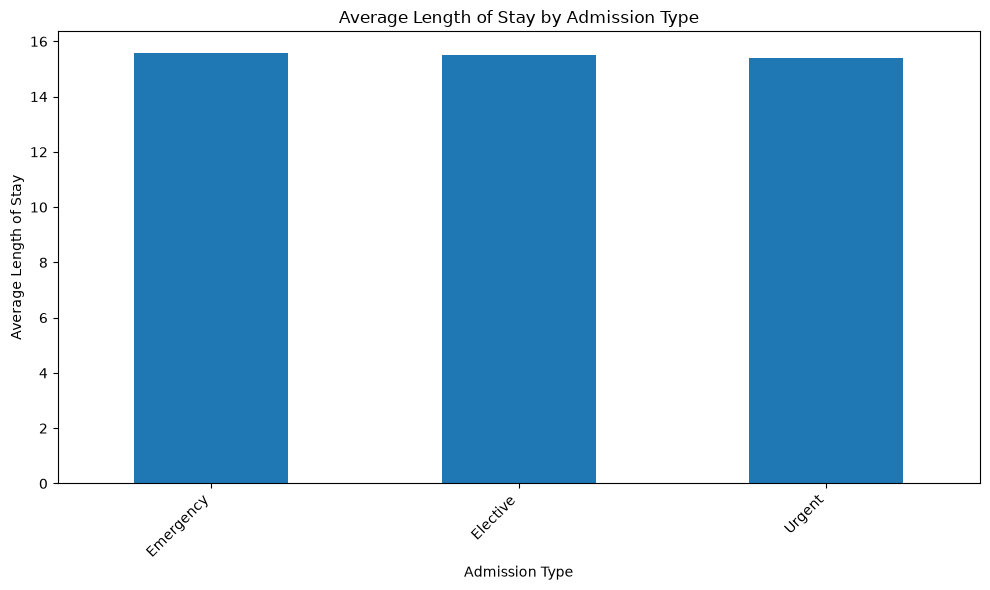

In [19]:
# Average Length of Stay by Admission Type
average_length_of_stay_admission_type = health_data_cleaned.groupby('Admission Type')['Length of Stay'].mean().sort_values(ascending=False)
average_length_of_stay_admission_type.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Admission Type')
plt.ylabel('Average Length of Stay')
plt.title('Average Length of Stay by Admission Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [28]:
new_numerical_columns = numerical_columns.append(pd.Index(['Length of Stay', 'Admission Year', 'Admission Month', 'Admission Day of Week']))

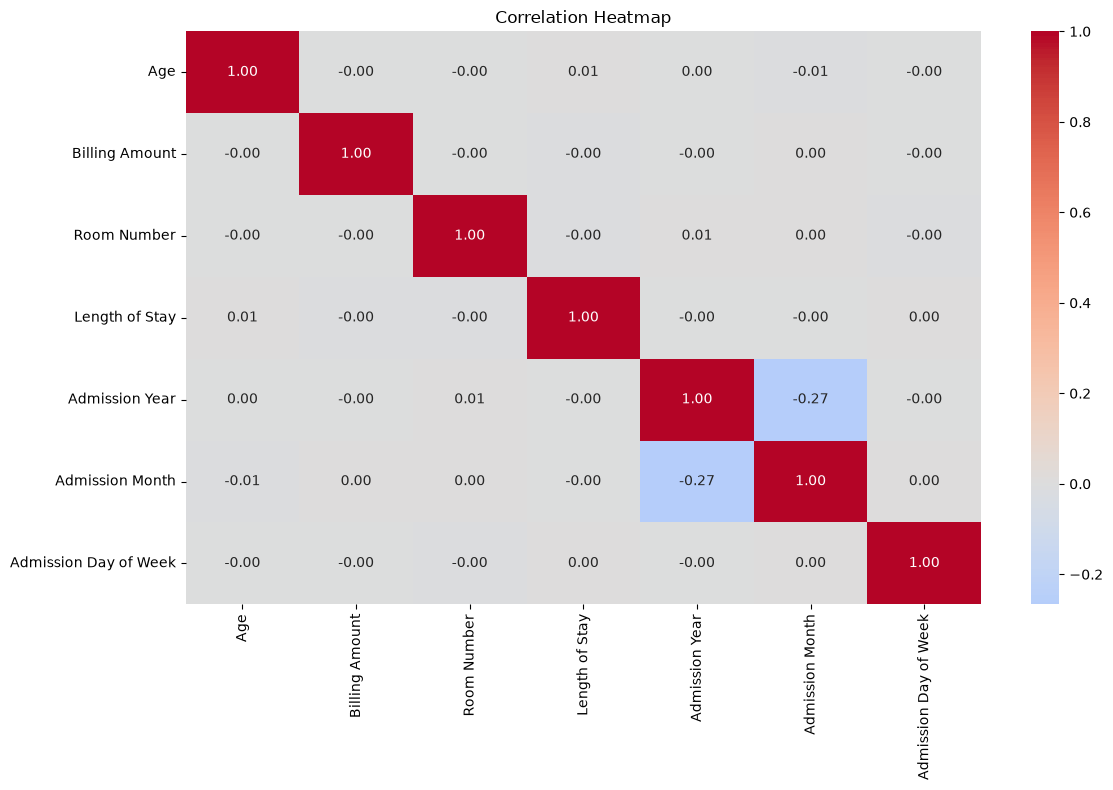

In [29]:
correlation_matrix = health_data_cleaned[new_numerical_columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()